In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

In [2]:
tau = [0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
sys = [ct.tf([1], [t, 1], name=str(t).replace('.', '_')) for t in tau]

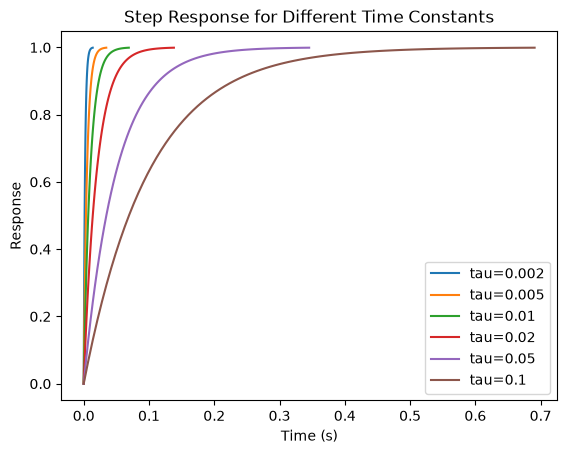

In [3]:
plt.figure()
for i in range(len(tau)):
    t, y = ct.step_response(sys[i])
    plt.plot(t, y, label=f'tau={tau[i]}')
plt.title('Step Response for Different Time Constants')
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.legend()

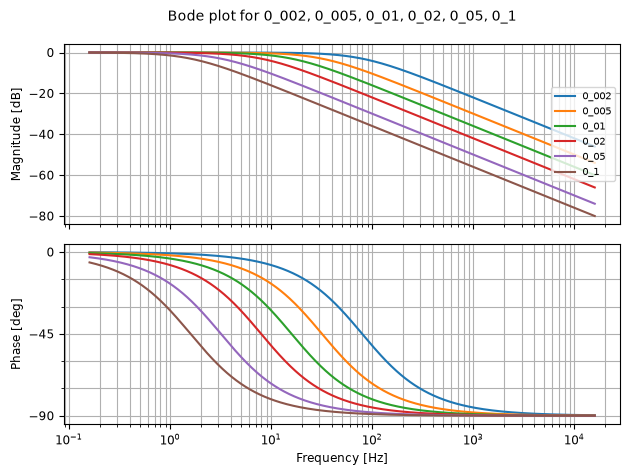

In [4]:
freq_response = ct.frequency_response(sys)
ct.bode_plot(sys, dB=True, Hz=True, omega=np.logspace(0, 5, 1000))

0.09188814923696534


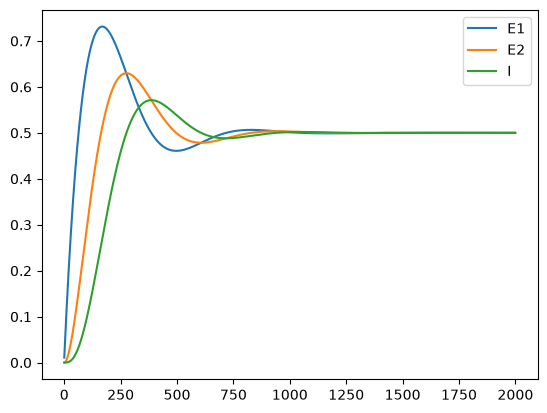

In [5]:
def cpg_step(D, E1, E2, I, O1, O2, OI, tau, W1, W2, WI, dt):
    E1_next = E1 + dt/tau * (-E1 +  - WI * OI + D)
    E2_next = E2 + dt/tau * (-E2 + W1 * O1)
    I_next = I + dt/tau * (-I + W2 * O2)
    O1_next = np.clip(E1_next, 0, 1)
    O2_next = np.clip(E2_next, 0, 1)
    OI_next = np.clip(I_next, 0, 1)
    return E1_next, E2_next, I_next, O1_next, O2_next, OI_next

def simulate_cpg(D, tau, W1, W2, WI, dt, T):
    time_steps = int(T / dt)
    E1, E2, I, O1, O2, OI = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    E1_history, E2_history, I_history = [], [], []
    
    for _ in range(time_steps):
        E1, E2, I, O1, O2, OI = cpg_step(D, E1, E2, I, O1, O2, OI, tau, W1, W2, WI, dt)
        E1_history.append(E1)
        E2_history.append(E2)
        I_history.append(I)
    
    return np.array(E1_history), np.array(E2_history), np.array(I_history)

def calc_tau(freq):
    return np.sqrt(3) / (2 * np.pi * freq)

freq = 3
tau = calc_tau(freq)
print(tau)
T = 2.0
dt = 0.001
E1, E2, I = simulate_cpg(D=1.0, tau=tau, W1=1.0, W2=1.0, WI=1.0, dt=dt, T=T)
plt.figure()
plt.plot(E1, label='E1')
plt.plot(E2, label='E2')
plt.plot(I, label='I')
plt.legend()
plt.show()

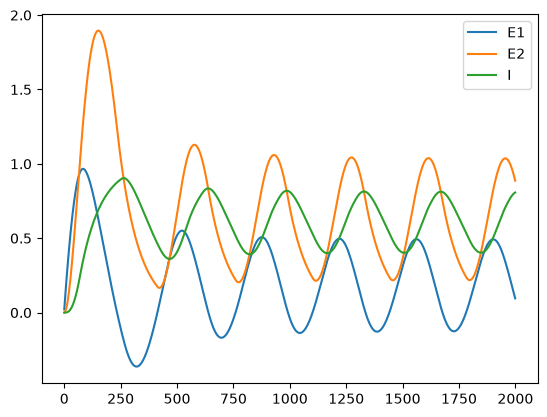

In [7]:
E1, E2, I = simulate_cpg(D=2.0, tau=tau, W1=3.0, W2=1.0, WI=3.0, dt=dt, T=2)
plt.figure()
plt.plot(E1, label='E1')
plt.plot(E2, label='E2')
plt.plot(I, label='I')
plt.legend()
plt.savefig('cpgSim.svg', format='svg')
plt.show()